In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# Regression

In [2]:
df = pd.read_csv('finale01_preprocessed.csv')
# Droppa name da df
#df = df.drop(columns=['Name'])
# Droppa NumWeightVotes, NumUserRatings, NumAlternates, NumExpansions, NumImplementations
df = df.drop(columns=['NumWeightVotes', 'NumUserRatings', 'NumAlternates', 'NumExpansions', 'NumImplementations'])


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. IDENTIFICA potenziali target (variabili numeriche continue)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Escludi ID, variabili binarie, e categoriche codificate
potential_targets = [col for col in numeric_cols 
                     if not col.startswith('Cat:')  # Escludi categoriche
                     and df[col].nunique() > 20]     # Escludi binarie

print("Potenziali target:")
for col in potential_targets:
    print(f"\n{col}:")
    print(f"  - Missing: {df[col].isna().sum()} ({df[col].isna().sum()/len(df)*100:.1f}%)")
    print(f"  - Range: [{df[col].min():.2f}, {df[col].max():.2f}]")
    print(f"  - Std Dev: {df[col].std():.2f}")
    print(f"  - Unique values: {df[col].nunique()}")

Potenziali target:

YearPublished:
  - Missing: 0 (0.0%)
  - Range: [1950.00, 2021.00]
  - Std Dev: 12.69
  - Unique values: 72

GameWeight:
  - Missing: 0 (0.0%)
  - Range: [1.00, 5.00]
  - Std Dev: 0.79
  - Unique values: 3839

ComAgeRec:
  - Missing: 0 (0.0%)
  - Range: [2.00, 21.00]
  - Std Dev: 2.94
  - Unique values: 1330

InterestScore:
  - Missing: 0 (0.0%)
  - Range: [2.00, 8671.26]
  - Std Dev: 1210.96
  - Unique values: 4345

log_NumWeightVotes:
  - Missing: 0 (0.0%)
  - Range: [0.00, 8.95]
  - Std Dev: 1.37
  - Unique values: 756

PlaytimeComAvg:
  - Missing: 0 (0.0%)
  - Range: [1.00, 480.00]
  - Std Dev: 77.37
  - Unique values: 134

log_NumUserRatings:
  - Missing: 0 (0.0%)
  - Range: [3.43, 11.59]
  - Std Dev: 1.45
  - Unique values: 3084

NumAlternates_log:
  - Missing: 0 (0.0%)
  - Range: [0.00, 6.75]
  - Std Dev: 0.70
  - Unique values: 51

NumExpansions_log:
  - Missing: 0 (0.0%)
  - Range: [0.00, 3.30]
  - Std Dev: 0.68
  - Unique values: 27

InterestScore_log:
  -

In [4]:
# Faccio merge con il file DM1_game_dataset per prendere GameWeight
df_weight = pd.read_csv('DM1_game_dataset.csv', usecols=['Name', 'GameWeight'])
df = df.merge(df_weight, on='Name', how='left')

df_weight

,Name,GameWeight
0,Assassin's Creed: Arena,1.8333
1,Bag of Chips,1.0000
2,Gùgōng: Deluxe Big Box,3.6667
3,LetterFlip,1.3077
4,Treasures of Cibola,1.5000
...,...,...
21920,Ballast,1.0000
21921,Leapfrog,1.5000
21922,Athos,1.6667
21923,Hoplomachus: Origins,3.0370


In [5]:
# Elimina il GameWeight vecchio
df = df.drop(columns=['GameWeight_x'])

# Rinomina quello nuovo
df = df.rename(columns={'GameWeight_y': 'NewGameWeight'})


In [6]:
# Quanti 0 ha df?
num_zeros = (df['NewGameWeight'] == 0).sum()
print(f'Numero di 0 in NewGameWeight: {num_zeros}')

# Calcola i NaN di MedGameWeight
num_nans = df['NewGameWeight'].isna().sum()
print(f'Numero di NaN in NewGameWeight: {num_nans}')

# Calcola mediana di GameWeight
# median_weight = df.loc[df['MedGameWeight'] > 0, 'MedGameWeight'].median()

# print(f'Mediana di MedGameWeight: {median_weight}')

# df['MedGameWeight'] = df['MedGameWeight'].replace(0, np.nan)
# df['MedGameWeight'] = df['MedGameWeight'].fillna(median_weight)

# Drop the rows where MedGameWeight is 0
df = df[df['NewGameWeight'] != 0]
# Drop the rows where MedGameWeight is NaN



Numero di 0 in NewGameWeight: 491
Numero di NaN in NewGameWeight: 0


In [7]:
# Quanti 0 ci sono in MedianGameWeight?
num_zeros_weight = (df['NewGameWeight'] == 0).sum()
print(f'Numero di 0 in NewGameWeight: {num_zeros_weight}')

Numero di 0 in NewGameWeight: 0


In [8]:
df = df.drop(columns=['Name'])

Prima avevo fatto questo: per usare GameWeight come target, ho ripreso la feature originale imputando gli 0 con la mediana globale e non con la mediana data dalle Cat  
MA poi ho visto che NON si può imputare una feature TARGET, quindi ho ripreso la feature originaria e ho cancellato gli 0 (perché così posso usare le Cat:*)

In [9]:
# Calculate correlation Sperman
correlations = {}
for column in df.columns:
    if column != 'NewGameWeight':
        corr, _ = spearmanr(df[column], df['NewGameWeight'])
        correlations[column] = corr
# Sort correlations
sorted_correlations = dict(sorted(correlations.items(), key=lambda item: abs(item[1]), reverse=True))
print("Spearman correlations with NewGameWeight:")
for column, corr in sorted_correlations.items():
    print(f"{column}: {corr}")
    


Spearman correlations with NewGameWeight:
PlaytimeComAvg: 0.6926106072760405
ComAgeRec: 0.6146626289601289
Rating: 0.46791200356589296
Cat:War: 0.43929367643382267
Cat:Strategy: 0.2976439869121246
log_NumWeightVotes: 0.29538007522385584
MaxPlayers: -0.28955130484091024
InterestScore: 0.2571748741847257
InterestScore_log: 0.2571748741847257
NumExpansions_log: 0.24056889247037108
Cat:Childrens: -0.24026365024323917
MinPlayers: -0.19057798972546652
NumAlternates_log: -0.17365629187205164
Cat:Party: -0.15313873715757195
Cat:Family: -0.14863499756182535
log_NumUserRatings: 0.14564426876341255
Cat:Thematic: 0.14348996061481245
Kickstarted: 0.10503722280720991
Cat:CGS: 0.06727066730592432
NumImplementations_log: 0.04682196164822572
IsReimplementation: 0.037460280449181524
Cat:Abstract: -0.010305802658004267
YearPublished: -0.009760372191463751


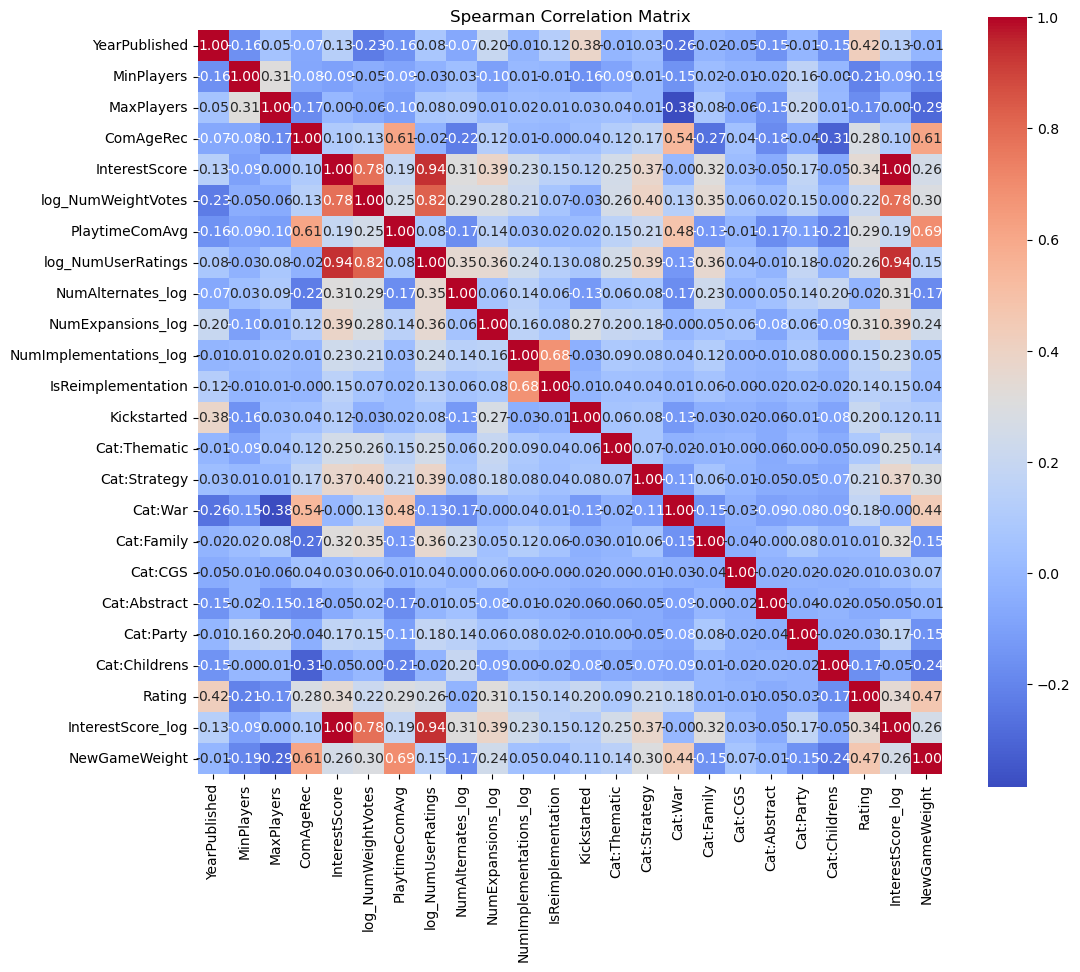

In [10]:
# Sperman correlation between all the features
corr_matrix = df.corr(method='spearman')
# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Spearman Correlation Matrix')
plt.show()



In [11]:
# Calcola la matrice di Spearman
corr_matrix = df.corr(method='spearman')

# Filtra le correlazioni: prendiamo il valore assoluto > 0.5 
# Escludiamo la correlazione 1.0 (la diagonale, cioè la variabile con se stessa)
strong_corr = corr_matrix[abs(corr_matrix) > 0.5]

# Formatta per la stampa: rimuove i duplicati e i valori nulli risultanti dal filtro
unstacked = strong_corr.unstack().drop_duplicates().dropna()
unstacked = unstacked[unstacked != 1.0]

print("Coppie di variabili con correlazione di Spearman > 0.5 o < -0.5:")
print(unstacked.sort_values(ascending=False))


Coppie di variabili con correlazione di Spearman > 0.5 o < -0.5:
InterestScore           log_NumUserRatings    0.936172
log_NumWeightVotes      log_NumUserRatings    0.822538
InterestScore           log_NumWeightVotes    0.782851
PlaytimeComAvg          NewGameWeight         0.692611
NumImplementations_log  IsReimplementation    0.676108
ComAgeRec               NewGameWeight         0.614663
                        PlaytimeComAvg        0.613102
                        Cat:War               0.538792
dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['NewGameWeight'])
y = df['NewGameWeight']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### Univariate Regression - Target = NewGameWeight; Var indipendente = ComAgeRec  
Correlazione NewGameWeight - ComAgeRec: 0.61

In [13]:
train_continuous = pd.concat([X_train, y_train], axis=1)
test_continuous  = pd.concat([X_test, y_test], axis=1)

x_train = train_continuous["ComAgeRec"].values.reshape(-1, 1)
y_train = train_continuous["NewGameWeight"].values

x_test  = test_continuous["ComAgeRec"].values.reshape(-1, 1)
y_test  = test_continuous["NewGameWeight"].values


### Linear Regression

Coefficients: 
 [0.16272517]
Intercept: 
 0.39196174667925954


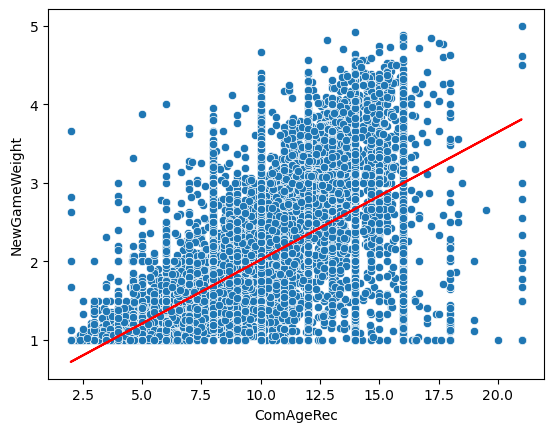

In [14]:
regLinear = LinearRegression()
regLinear.fit(x_train, y_train)

print('Coefficients: \n', regLinear.coef_)
print('Intercept: \n', regLinear.intercept_)

sns.scatterplot(data=train_continuous, x="ComAgeRec", y="NewGameWeight")
plt.plot(x_train, regLinear.coef_[0]*x_train+regLinear.intercept_, c="red")

In [15]:
y_pred = regLinear.predict(x_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.361
MSE: 0.412
MAE: 0.493


### Ridge

Coefficients: 
 [0.1627241]
Intercept: 
 0.3919725986563465


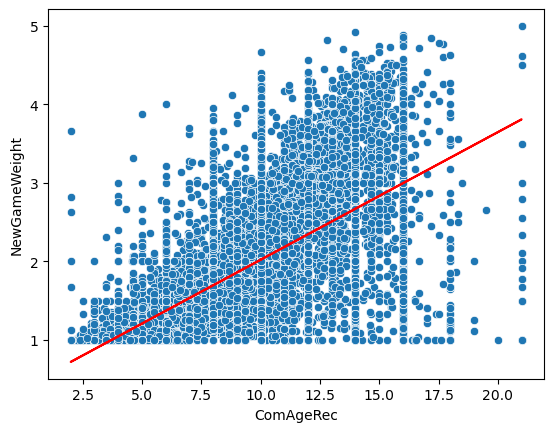

In [16]:
regRidge = Ridge()
regRidge.fit(x_train, y_train)
print('Coefficients: \n', regRidge.coef_)
print('Intercept: \n', regRidge.intercept_)

sns.scatterplot(data=train_continuous, x="ComAgeRec", y="NewGameWeight")
plt.plot(x_train, regRidge.coef_[0]*x_train+regRidge.intercept_, c="red")

In [17]:
y_pred = regRidge.predict(x_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.361
MSE: 0.412
MAE: 0.493


### Lasso

In [18]:
# Create and train the model
regLasso  = Lasso(alpha=0.01).fit(x_train, y_train)

# Make predictions
y_pred = regLasso.predict(x_test)

print('Coefficients:', regLasso.coef_)
print('Intercept:', regLasso.intercept_)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

print("X_train shape:", x_train.shape)



Coefficients: [0.16158209]
Intercept: 0.4035150230633118
R2: 0.361
MSE: 0.412
MAE: 0.493
X_train shape: (17324, 1)


# Multiple Regression

## Linear with 2+ indipendent variables
X = [ComAgeRec, PlaytimeComAvg, Rating]  


Correlazioni con il target NewGameWeight:  
PlaytimeComAvg: 0.6926201165455091  
ComAgeRec: 0.6146626289601289  
Rating: 0.46791200356589296  

In [19]:
X = df[['ComAgeRec', 'PlaytimeComAvg', 'Rating']]
y = df['NewGameWeight']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Linear Regression (Multiple)

In [21]:
reg_multi = LinearRegression().fit(X_train, y_train)

print("Coefficients:")
for name, coef in zip(X.columns, reg_multi.coef_):
    print(f"  {name}: {coef:.4f}")

print(f"Intercept: {reg_multi.intercept_:.4f}")

print()
y_pred = reg_multi.predict(X_test)

print(f"R2:  {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")




Coefficients:
  ComAgeRec: 0.0887
  PlaytimeComAvg: 0.0038
  Rating: 0.3062
Intercept: 0.2980

R2:  0.552
MSE: 0.288
MAE: 0.415


### Lasso Regression (Multiple)

In [22]:
# Create and train the model
regLasso  = Lasso(alpha=0.01).fit(X_train, y_train)

# Make predictions
y_pred = regLasso.predict(X_test)

print('Coefficients:', regLasso.coef_)
print('Intercept:', regLasso.intercept_)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

# print("X_train shape:", X_train.shape)
# print("Columns:", list(X_train.columns))


Coefficients: [0.08810071 0.00386038 0.28704476]
Intercept: 0.3368163929147645
R2: 0.552
MSE: 0.289
MAE: 0.416


### Ridge (Multiple)

In [23]:

# Ridge regression (MULTIVARIATA: 3 feature)
regRidge = Ridge(alpha=1.0, random_state=42)  # alpha default = 1.0
regRidge.fit(X_train, y_train)

# Coefficienti e intercetta
print("Coefficients:")
for name, coef in zip(X.columns, regRidge.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {regRidge.intercept_:.4f}")

# Predizioni e metriche su TEST
y_pred = regRidge.predict(X_test)

print(f"R2:  {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")


Coefficients:
  ComAgeRec: 0.0887
  PlaytimeComAvg: 0.0038
  Rating: 0.3062
Intercept: 0.2981
R2:  0.552
MSE: 0.288
MAE: 0.415


## Non-linear with 2+ indipendent variables

### Decision Tree Regressor (Non-linear)

In [24]:
# Decision Tree Regressor

# GridSearch for hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# Best model
best_tree = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Train and evaluate the model
best_tree.fit(X_train, y_train)
y_pred = best_tree.predict(X_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))



Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
R2: 0.614
MSE: 0.248
MAE: 0.377


### KNN Regression (Non-linear)

In [25]:
# Mini cross-validation to find the best k
k_values = range(1, 21)  # Test k from 1 to 20
mean_r2_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    r2_scores = []
    
    # Perform cross-validation
    for train_idx, val_idx in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        
        knn.fit(X_train_fold, y_train_fold)
        y_val_pred = knn.predict(X_val_fold)
        r2_scores.append(r2_score(y_val_fold, y_val_pred))
    
    mean_r2_scores.append(np.mean(r2_scores))

# Find the best k
best_k = k_values[np.argmax(mean_r2_scores)]
print(f"Best k: {best_k} with R2: {max(mean_r2_scores):.3f}")


Best k: 20 with R2: 0.609


In [26]:
# Train the KNN Regressor with the best k
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_best.predict(X_test)

# Evaluate the model on the test set
print('Test R2: %.3f' % r2_score(y_test, y_pred))
print('Test MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('Test MAE: %.3f' % mean_absolute_error(y_test, y_pred))

Test R2: 0.602
Test MSE: 0.256
Test MAE: 0.383
